In [42]:
# =============================================================================
# Titanic Classification: Decision Tree / Random Forest / SVM / Ensemble
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

# Ensure plots render inside notebook output.
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)

# ── Classifiers
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

import duckdb
def esql(query):
    return duckdb.sql(query).df()

import warnings
warnings.filterwarnings('ignore')



In [2]:
# =============================================================================
# 1. DATA LOADING & PREPROCESSING
# =============================================================================
print("=" * 60)
print("1. Loading Titanic Dataset")
print("=" * 60)

titanic = fetch_openml("titanic", version=1, as_frame=True, parser='auto')
df = titanic.frame.copy()
print(df.head())

# Select features and drop missing values
df = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'survived']].dropna()
df['sex']      = LabelEncoder().fit_transform(df['sex'])   # female=0, male=1
df['pclass']   = df['pclass'].astype(float)
df['survived'] = df['survived'].astype(int)

print(f"Dataset shape  : {df.shape}")
print(f"Survival rate  : {df['survived'].mean():.1%}")
print(df.head())



1. Loading Titanic Dataset
   pclass survived                                             name     sex  \
0       1        1                    Allen, Miss. Elisabeth Walton  female   
1       1        1                   Allison, Master. Hudson Trevor    male   
2       1        0                     Allison, Miss. Helen Loraine  female   
3       1        0             Allison, Mr. Hudson Joshua Creighton    male   
4       1        0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0   

In [22]:
# Features / Labels
X = df.drop('survived', axis=1)
y = df['survived']

# Train / Test split  (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train_df = pd.DataFrame(y_train)
y_test_df  = pd.DataFrame(y_test)
print("train target ratio : ", y_train_df.mean())
print("test target ratio  : ", y_test_df.mean())

# StandardScaler (required for SVM)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain size: {len(X_train)}  |  Test size: {len(X_test)}")

train target ratio :  survived    0.409091
dtype: float64
test target ratio  :  survived    0.406699
dtype: float64

Train size: 836  |  Test size: 209


In [25]:
# =============================================================================
# 2. DECISION TREE
# =============================================================================
print("\n" + "=" * 60)
print("2. Decision Tree Classifier")
print("=" * 60)

# --- 2-1. Train
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# --- 2-2. Predict & Evaluate
y_pred_dt = dt.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt,
                             target_names=['Not Survived', 'Survived']))


2. Decision Tree Classifier
Accuracy : 0.8230
              precision    recall  f1-score   support

Not Survived       0.80      0.94      0.86       124
    Survived       0.89      0.65      0.75        85

    accuracy                           0.82       209
   macro avg       0.84      0.80      0.81       209
weighted avg       0.83      0.82      0.82       209



In [26]:
# --- 2-3. Feature Importance
fi_dt = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importance:")
print(fi_dt)

Feature Importance:
sex       0.563736
pclass    0.207809
age       0.124823
sibsp     0.055632
fare      0.048000
parch     0.000000
dtype: float64


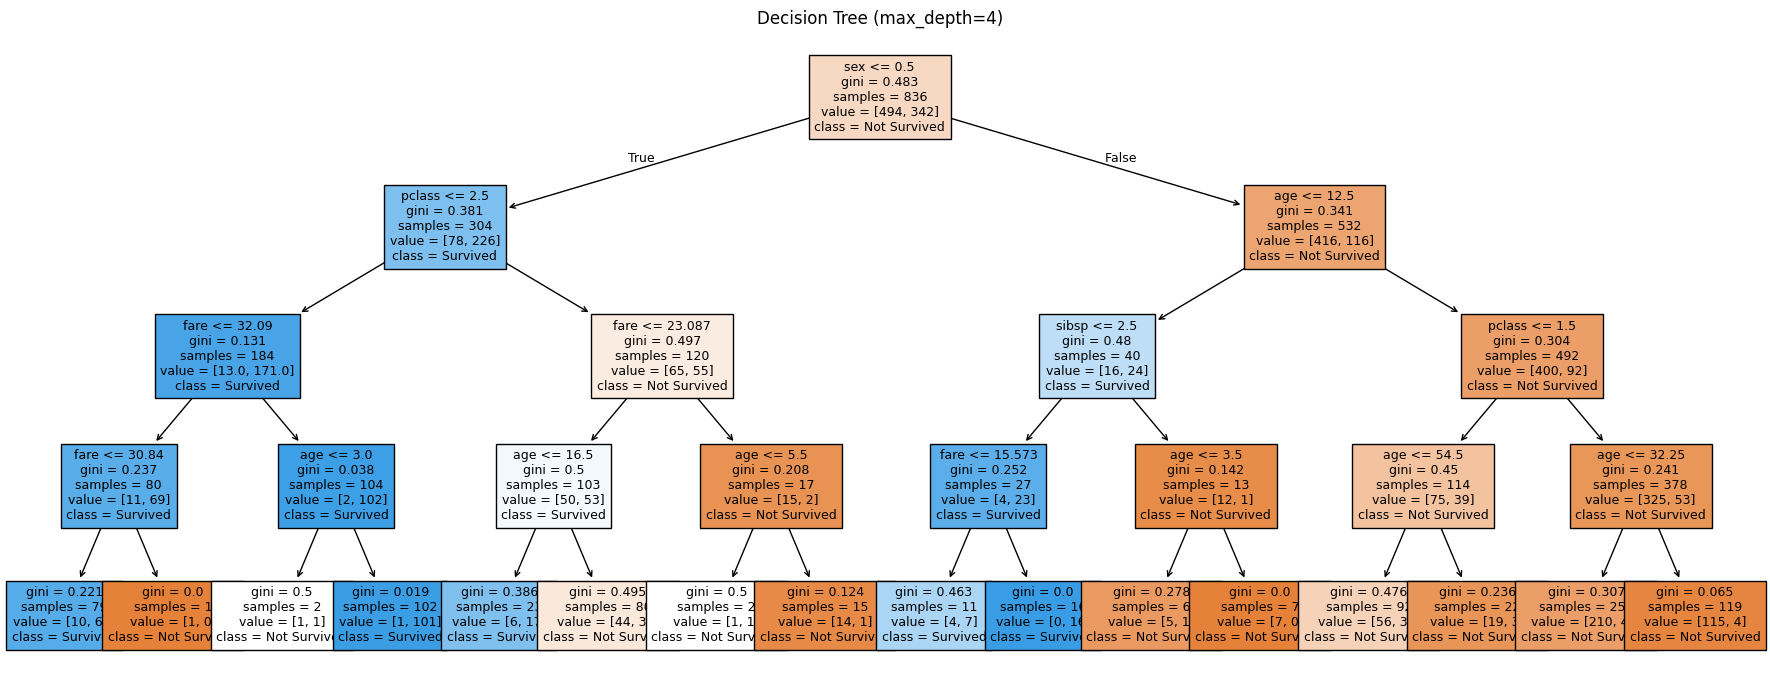

In [29]:
# --- 2-4. Visualize tree
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=['Not Survived', 'Survived'],
    filled=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree (max_depth=4)")
fig.tight_layout()
plt.show()

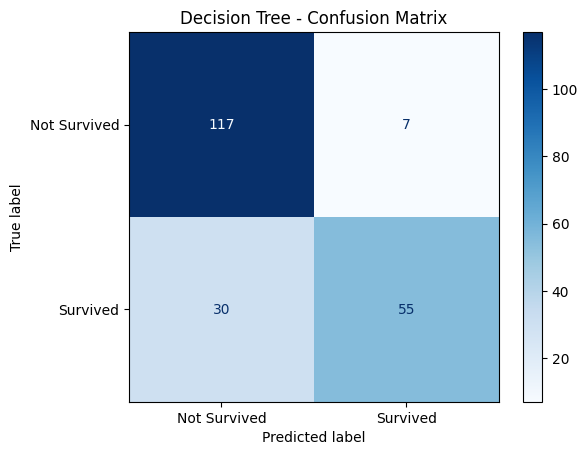

In [30]:
# --- 2-5. Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm, display_labels=['Not Survived', 'Survived']).plot(cmap='Blues')
plt.title("Decision Tree - Confusion Matrix")
plt.show()
plt.close()

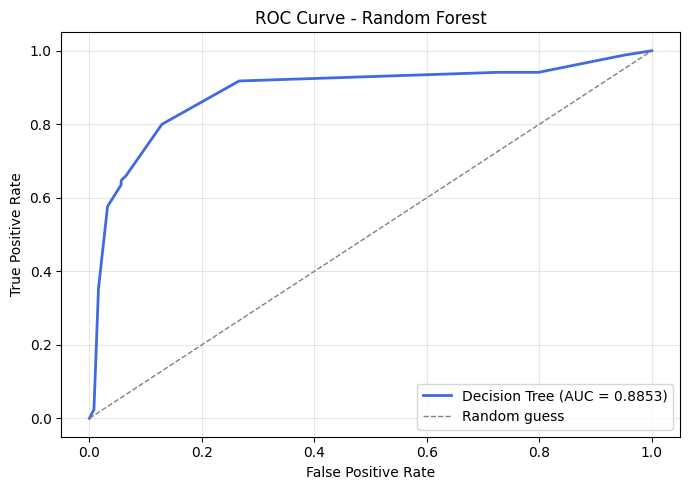

In [43]:
# 1) 양성 클래스 확률
y_score = dt.predict_proba(X_test)[:, 1]

# 2) ROC 좌표 + AUC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc_score = roc_auc_score(y_test, y_score)

# 3) 그래프
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='royalblue', lw=2, label=f'Decision Tree (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# =============================================================================
# 3. RANDOM FOREST
# =============================================================================
print("\n" + "=" * 60)
print("3. Random Forest Classifier")
print("=" * 60)

# --- 3-1. Train
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# --- 3-2. Predict & Evaluate
y_pred_rf = rf.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf,
                             target_names=['Not Survived', 'Survived']))




3. Random Forest Classifier
Accuracy : 0.8612
              precision    recall  f1-score   support

Not Survived       0.84      0.95      0.89       124
    Survived       0.91      0.73      0.81        85

    accuracy                           0.86       209
   macro avg       0.87      0.84      0.85       209
weighted avg       0.87      0.86      0.86       209



Feature Importance:
sex       0.437763
fare      0.176164
pclass    0.153469
age       0.131741
parch     0.055099
sibsp     0.045764
dtype: float64


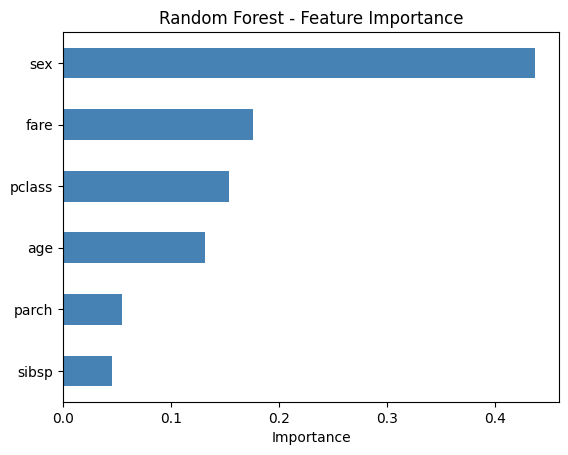

In [38]:
# --- 3-3. Feature Importance
fi_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importance:")
print(fi_rf)

fi_rf_plot = fi_rf.sort_values(ascending=True)
fi_rf_plot.plot(kind='barh', color='steelblue', title='Random Forest - Feature Importance')
ax.invert_yaxis() 
plt.xlabel('Importance')
# plt.savefig("rf_importance.png", bbox_inches='tight')
plt.show()
plt.close()



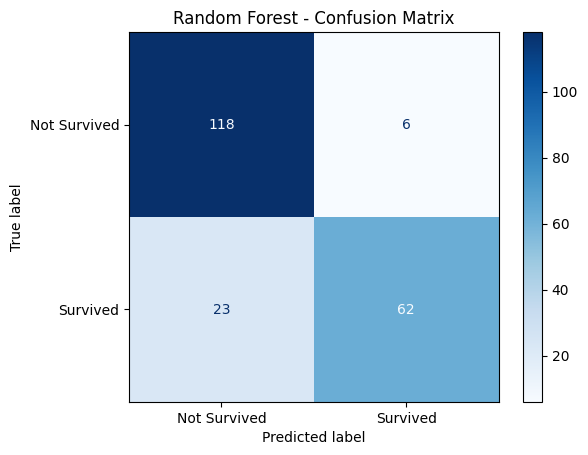

In [39]:
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=['Not Survived', 'Survived']).plot(cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.show()
plt.close()

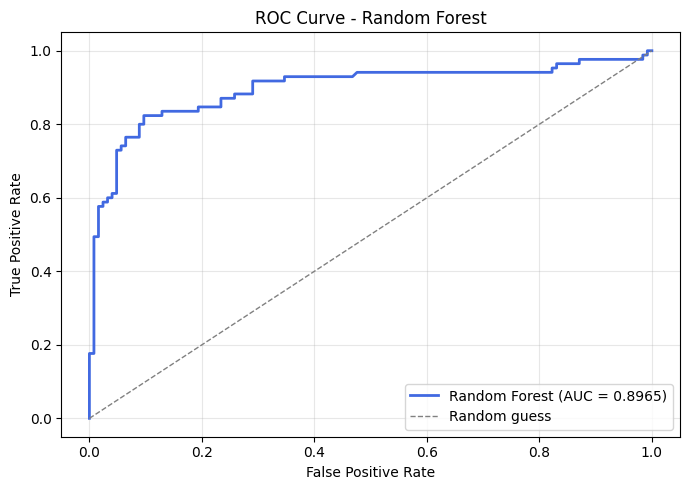

In [ ]:
# 1) 양성 클래스 확률
y_score = rf.predict_proba(X_test)[:, 1]

# 2) ROC 좌표 + AUC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc_score = roc_auc_score(y_test, y_score)

# 3) 그래프
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='royalblue', lw=2, label=f'Random Forest (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
# =============================================================================
# 4. SUPPORT VECTOR MACHINE (SVM)
# =============================================================================
print("\n" + "=" * 60)
print("4. Support Vector Machine (SVM)")
print("=" * 60)

# --- 4-1. Train (RBF kernel, scaled data)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_sc, y_train)

# --- 4-2. Predict & Evaluate
y_pred_svm = svm.predict(X_test_sc)
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm,
                             target_names=['Not Survived', 'Survived']))




4. Support Vector Machine (SVM)
Accuracy : 0.8565
              precision    recall  f1-score   support

Not Survived       0.84      0.94      0.89       124
    Survived       0.89      0.74      0.81        85

    accuracy                           0.86       209
   macro avg       0.86      0.84      0.85       209
weighted avg       0.86      0.86      0.85       209



In [47]:
# --- 4-3. Kernel comparison
print("Kernel Accuracy Comparison:")
for kernel in ['linear', 'poly', 'rbf', 'sigmoid']:
    svm_k = SVC(kernel=kernel, random_state=42)
    svm_k.fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, svm_k.predict(X_test_sc))
    print(f"  kernel={kernel:8s} | acc={acc:.4f}")



Kernel Accuracy Comparison:
  kernel=linear   | acc=0.8230
  kernel=poly     | acc=0.8469
  kernel=rbf      | acc=0.8565
  kernel=sigmoid  | acc=0.6938


In [48]:
# =============================================================================
# 5. ENSEMBLE METHODS
# =============================================================================
print("\n" + "=" * 60)
print("5. Ensemble Methods")
print("=" * 60)

# ── 5-1. BAGGING
print("\n[5-1] Bagging")
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=4),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    random_state=42
)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_bag):.4f}")
print(classification_report(y_test, y_pred_bag,
                             target_names=['Not Survived', 'Survived']))




5. Ensemble Methods

[5-1] Bagging
Accuracy : 0.8469
              precision    recall  f1-score   support

Not Survived       0.82      0.94      0.88       124
    Survived       0.90      0.71      0.79        85

    accuracy                           0.85       209
   macro avg       0.86      0.82      0.83       209
weighted avg       0.85      0.85      0.84       209



In [49]:
# ── 5-2. BOOSTING (Gradient Boosting)
print("\n[5-2] Gradient Boosting")
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(classification_report(y_test, y_pred_gb,
                             target_names=['Not Survived', 'Survived']))

# Feature Importance (GBM)
fi_gb = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)
print("GBM Feature Importance:")
print(fi_gb)




[5-2] Gradient Boosting
Accuracy : 0.8517
              precision    recall  f1-score   support

Not Survived       0.84      0.92      0.88       124
    Survived       0.86      0.75      0.81        85

    accuracy                           0.85       209
   macro avg       0.85      0.84      0.84       209
weighted avg       0.85      0.85      0.85       209

GBM Feature Importance:
sex       0.458054
pclass    0.182620
age       0.156683
fare      0.148249
sibsp     0.051447
parch     0.002948
dtype: float64


In [50]:
# ── 5-3. STACKING
print("\n[5-3] Stacking")
base_learners = [
    ('dt',  DecisionTreeClassifier(max_depth=4, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=50, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
]
stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=500),
    cv=5,
    passthrough=False
)
# Stacking uses scaled data (SVM base requires it)
stacking.fit(X_train_sc, y_train)
y_pred_st = stacking.predict(X_test_sc)
print(f"Accuracy : {accuracy_score(y_test, y_pred_st):.4f}")
print(classification_report(y_test, y_pred_st,
                             target_names=['Not Survived', 'Survived']))

# ── 5-4. VOTING (Soft)
print("\n[5-4] Voting Classifier (Soft)")
voting = VotingClassifier(
    estimators=[
        ('dt',  DecisionTreeClassifier(max_depth=4, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=50, random_state=42)),
        ('lr',  LogisticRegression(max_iter=500)),
    ],
    voting='soft'
)
voting.fit(X_train, y_train)
y_pred_vt = voting.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_vt):.4f}")
print(classification_report(y_test, y_pred_vt,
                             target_names=['Not Survived', 'Survived']))




[5-3] Stacking
Accuracy : 0.8469
              precision    recall  f1-score   support

Not Survived       0.83      0.93      0.88       124
    Survived       0.87      0.73      0.79        85

    accuracy                           0.85       209
   macro avg       0.85      0.83      0.84       209
weighted avg       0.85      0.85      0.84       209


[5-4] Voting Classifier (Soft)
Accuracy : 0.8565
              precision    recall  f1-score   support

Not Survived       0.85      0.92      0.88       124
    Survived       0.87      0.76      0.81        85

    accuracy                           0.86       209
   macro avg       0.86      0.84      0.85       209
weighted avg       0.86      0.86      0.85       209




6. Hyperparameter Tuning - GridSearchCV
[DT]  Best params : {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
[DT]  Best CV acc : 0.7990
[DT]  Test  acc   : 0.8517

[RF]  Best params : {'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 200}
[RF]  Best CV acc : 0.8014
[RF]  Test  acc   : 0.8565

[SVM] Best params : {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
[SVM] Best CV acc : 0.7979
[SVM] Test  acc   : 0.8469

7. Final Performance Summary
            Model  Accuracy  F1-Score  Precision
    Random Forest    0.8612    0.8105     0.8580
        SVM (RBF)    0.8565    0.8077     0.8539
    Voting (Soft)    0.8565    0.8125     0.8548
Gradient Boosting    0.8517    0.8050     0.8497
          Bagging    0.8469    0.7895     0.8430
         Stacking    0.8469    0.7949     0.8441
    Decision Tree    0.8230    0.7483     0.8166


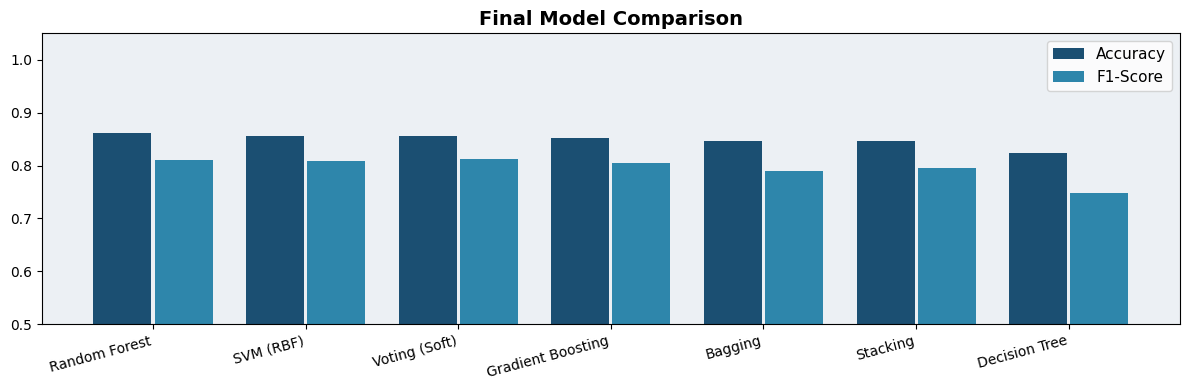

In [51]:
# =============================================================================
# 6. HYPERPARAMETER TUNING (GridSearchCV)
# =============================================================================
print("\n" + "=" * 60)
print("6. Hyperparameter Tuning - GridSearchCV")
print("=" * 60)

# --- Decision Tree
param_dt = {
    'max_depth': [3, 4, 5, 6, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
}
gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     param_dt, cv=5, scoring='accuracy', n_jobs=-1)
gs_dt.fit(X_train, y_train)
print(f"[DT]  Best params : {gs_dt.best_params_}")
print(f"[DT]  Best CV acc : {gs_dt.best_score_:.4f}")
print(f"[DT]  Test  acc   : {accuracy_score(y_test, gs_dt.predict(X_test)):.4f}")

# --- Random Forest
param_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 5, 7, None],
    'max_features': ['sqrt', 'log2'],
}
gs_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                     param_rf, cv=5, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_train, y_train)
print(f"\n[RF]  Best params : {gs_rf.best_params_}")
print(f"[RF]  Best CV acc : {gs_rf.best_score_:.4f}")
print(f"[RF]  Test  acc   : {accuracy_score(y_test, gs_rf.predict(X_test)):.4f}")

# --- SVM
param_svm = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear'],
}
gs_svm = GridSearchCV(SVC(random_state=42),
                      param_svm, cv=5, scoring='accuracy', n_jobs=-1)
gs_svm.fit(X_train_sc, y_train)
print(f"\n[SVM] Best params : {gs_svm.best_params_}")
print(f"[SVM] Best CV acc : {gs_svm.best_score_:.4f}")
print(f"[SVM] Test  acc   : {accuracy_score(y_test, gs_svm.predict(X_test_sc)):.4f}")

# =============================================================================
# 7. FINAL COMPARISON SUMMARY
# =============================================================================
print("\n" + "=" * 60)
print("7. Final Performance Summary")
print("=" * 60)

results = {
    'Decision Tree':      (y_pred_dt,  y_test),
    'Random Forest':      (y_pred_rf,  y_test),
    'SVM (RBF)':          (y_pred_svm, y_test),
    'Bagging':            (y_pred_bag, y_test),
    'Gradient Boosting':  (y_pred_gb,  y_test),
    'Stacking':           (y_pred_st,  y_test),
    'Voting (Soft)':      (y_pred_vt,  y_test),
}

summary = []
for name, (y_pred, y_true) in results.items():
    summary.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'F1-Score':  round(f1_score(y_true, y_pred), 4),
        'Precision': round(f1_score(y_true, y_pred, average='weighted'), 4),
    })

summary_df = pd.DataFrame(summary).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))

# Bar chart summary
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(summary_df))
ax.bar(x - 0.2, summary_df['Accuracy'], 0.38, label='Accuracy', color='#1B4F72')
ax.bar(x + 0.2, summary_df['F1-Score'], 0.38, label='F1-Score',  color='#2E86AB')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.set_title('Final Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_facecolor('#ECF0F4')
plt.tight_layout()
plt.show()
plt.close()